In [1]:
import json
import struct
import numpy as np
import matplotlib.pyplot as plt
import photonforge as pf
import siepic_forge as siepic
import luxtelligence_lnoi400_forge as lxt
import tidy3d as td

td.config.logging_level = "ERROR"


# Set up technologies
siepic_tech = siepic.ebeam()
basic_tech = pf.basic_technology()
lxt_tech = lxt.lnoi400()
pf.config.default_technology = siepic_tech

# Initialize live viewer for real-time visualization
from photonforge.live_viewer import LiveViewer
viewer = LiveViewer()

# Define simulation parameters
wavelengths = np.linspace(1.53, 1.57, 101)
freqs = pf.C_0 / wavelengths

LiveViewer started at http://localhost:58902


In [97]:
@pf.parametric_component
def create_mzi_siepic(*, name="mzi", coupling_distance=0.6, coupling_length=5.35, length=20, delta_length=0):

    # Bend and Straight waveguide to form the microring
    straight = pf.parametric.straight(port_spec="TE_1550_500", length=length)
    delta_straight = pf.parametric.straight(port_spec="TE_1550_500", length=delta_length/2)
    bend = pf.parametric.bend(port_spec="TE_1550_500", radius=5)
    y_branch = siepic.component("ebeam_y_1550")
    coupler = pf.parametric.dual_ring_coupler(
        port_spec="TE_1550_500", coupling_distance=coupling_distance, coupling_length=coupling_length, radius=5, 
        tidy3d_model_kwargs={
            # These symmetries are not correct for arbitrary ports.
            # They can be used in this case for the fundamental mode.
            "port_symmetries": [
                ("P1", "P0", "P3", "P2"),
                ("P2", "P3", "P0", "P1"),
                ("P3", "P2", "P1", "P0"),
            ],
        },
    )

    mzi = pf.Component(name)

    # form main microring structure
    cp1_ref = mzi.add_reference(coupler)
    bend1_ref = mzi.add_reference(bend)
    bend2_ref = mzi.add_reference(bend) 
    str1_ref = mzi.add_reference(straight)
    str2_ref = mzi.add_reference(straight)
    dstr1_ref = mzi.add_reference(delta_straight)
    # dstr2_ref = mzi.add_reference(delta_straight)
    yb1_ref = mzi.add_reference(y_branch)

    dstr1_ref.connect("P0", cp1_ref["P3"])
    bend1_ref.connect("P1", dstr1_ref["P1"])
    bend2_ref.connect("P0", cp1_ref["P2"])
    str1_ref.connect("P0", bend1_ref["P0"])
    str2_ref.connect("P0", bend2_ref["P1"])

    yb1_ref.rotate(180)
    yb1_ref.y_mid = cp1_ref.y_mid
    yb1_ref.x_min = str1_ref.x_max + length

    route_yb1_1 = pf.parametric.route(port1=(str1_ref, "P1"), port2=(yb1_ref, "P1"), radius=5)
    route_yb1_2 = pf.parametric.route(port1=(str2_ref, "P1"), port2=(yb1_ref, "P2"), radius=5)
    mzi.add_reference(route_yb1_1)
    mzi.add_reference(route_yb1_2)

    ## COMPONENT MODELS
    mzi.add_port(cp1_ref["P0"], "P0")
    mzi.add_port(cp1_ref["P1"], "P1")
    mzi.add_port(yb1_ref["P0"], "P2")
    mzi.add_model(pf.CircuitModel(), "CircuitModel")

    # port_symmetries = [
    #     ("P1", "P0", "P2"),
    # ]

    # field_monitor = td.FieldMonitor(
    #     center=(0, 0, 0.11), size=(td.inf, td.inf, 0), freqs=[freqs.mean()], name="field"
    # )

    # mzi.add_model(pf.Tidy3DModel(port_symmetries=port_symmetries, monitors=[field_monitor]), "Tidy3DModel")

    return mzi

mzi = create_mzi_siepic(length=10, delta_length=1.58)
viewer(mzi)

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\parametric_utils.py:208: RuntimeWarning: Component function '__main__.create_mzi_siepic' previously registered will be overwritten.
  return _decorator(decorated_function)


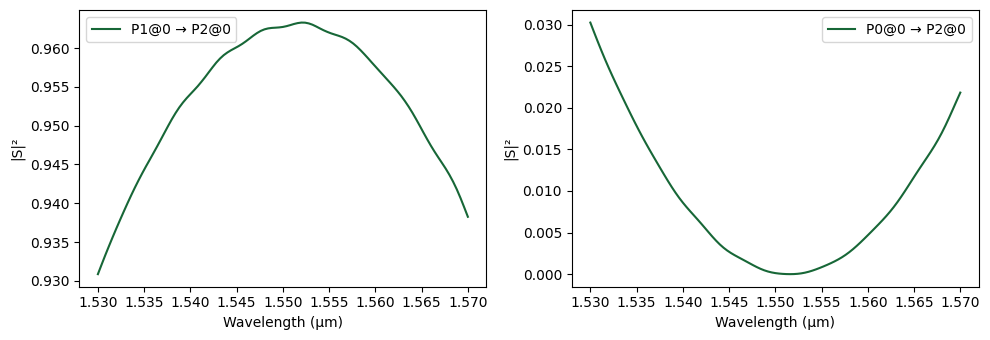

In [98]:
s_matrix = mzi.s_matrix(freqs, model_kwargs={"inputs": ["P0@0", "P1@0"]})
fig, ax = pf.plot_s_matrix(s_matrix, input_ports=["P0", "P1"], output_ports=["P2", "P3"], y="db")

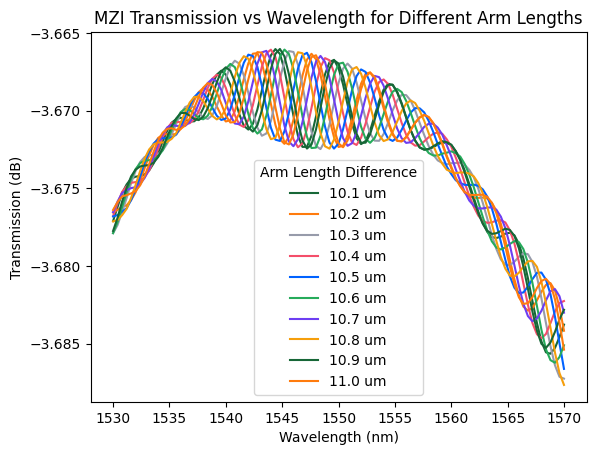

In [84]:
lengths = [10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11.0]

fig, ax = plt.subplots()

for length in lengths:
    mzi = create_mzi_siepic(length=length)
    s_matrix = mzi.s_matrix(freqs, model_kwargs={"inputs": ["P0@0"]})
    s2 = s_matrix[("P0@0", "P2@0")]
    ax.plot(
        wavelengths * 1e3,
        10*np.log(np.abs(s2)),
        label=f"{length} um",
        linewidth=1.5,
    )

ax.legend(title="Arm Length Difference")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Transmission (dB)")
ax.set_title("MZI Transmission vs Wavelength for Different Arm Lengths")

plt.show()

c:\Users\irfan\AppData\Local\Programs\Python\Python313\Lib\site-packages\photonforge\tidy3d_model.py:1346: FutureWarning: Methods 'batch_data_for', 'batch_file_for', and 'data_path_for' are deprecated and they will be removed in the next release. Use 'Tidy3DModel.batch_data' to retrieve simulation data.
  self.data_path_for(component, _skip_warning=_skip_warning) / f"batch_data-{suffix}.json"


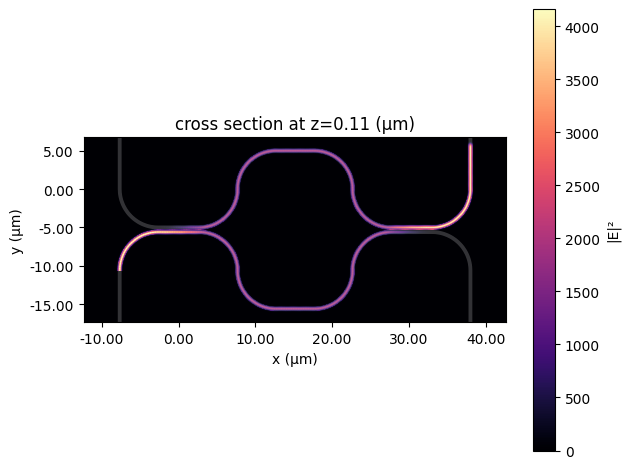

In [12]:
sim_data = mzi.active_model.batch_data_for(mzi)
_ = sim_data["P0@0"].plot_field("field", "E", val="abs^2", robust=False)